In [4]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field

load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

In [5]:
from typing import TypedDict
from langchain_core.messages import SystemMessage,HumanMessage
from IPython.display import display,Image

class ParentState(TypedDict):
    parent_input:str
    parent_answer:str 

def parent_node(state:ParentState)->ParentState:
    messages=state['parent_input']
    result=llm.invoke(messages)
    return {'parent_answer':result.content}
    
class SubState(TypedDict):
    sub_input:str
    summary_answer:str
    score:str

def subgraph_node1(state:SubState)-> SubState:
    system_prompt="将收到的消息总结，总结成不超过30个字"
    answer=state['sub_input']
    result=llm.invoke([SystemMessage(content=system_prompt),HumanMessage(content=
                                                                         answer)])
    print('subgraph_node1',result)
    return {'sub_input':answer,'summary_answer':result.content}

def subgraph_node2(state:SubState)-> SubState:
    system_prompt="分析拿到的回答和总结后的回答，进行打分，满分10分"
    result=llm.invoke([SystemMessage(content=system_prompt),HumanMessage(content=state['sub_input']),
                HumanMessage(content=state['summary_answer'])])
    return {'score':result}

In [6]:
from langgraph.graph import END, START, StateGraph


subgraph_builder=StateGraph(SubState)

subgraph_builder.add_node('subgraph_node1',subgraph_node1)
subgraph_builder.add_node('subgraph_node2',subgraph_node2)

subgraph_builder.add_edge(START,'subgraph_node1')
subgraph_builder.add_edge('subgraph_node1','subgraph_node2')
subgraph_builder.add_edge('subgraph_node2',END)

subgraph=subgraph_builder.compile()

In [7]:
def parent_node_start(state:ParentState)-> SubState:
    messages=state['parent_answer']
    result=subgraph.invoke({'sub_input':messages})
    return {'parent_answer':result['score'].content}


In [8]:
parent_builder=StateGraph(ParentState)

parent_builder.add_node('parent_node',parent_node)
parent_builder.add_node('parent_node_start',parent_node_start)

# parent_builder.add_node('subgraph',subgraph)
# parent_builder.add_node('parent_node_end',parent_node_end)

parent_builder.add_edge(START,'parent_node')
parent_builder.add_edge('parent_node','parent_node_start')
# parent_builder.add_edge('parent_node_start','subgraph')
# parent_builder.add_edge('subgraph','parent_node_end')
parent_builder.add_edge('parent_node_start',END)

parent_graph=parent_builder.compile()

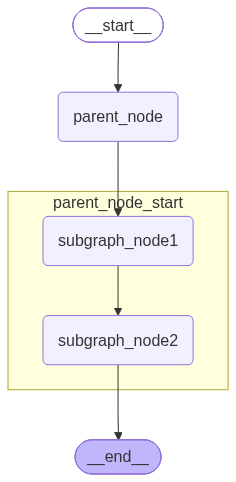

In [9]:
display(Image(parent_graph.get_graph(xray=True).draw_mermaid_png()))
# print(parent_graph.get_graph().draw_mermaid())


# from langchain_core.runnables.graph import MermaidDrawMethod

# display(Image(
#     parent_graph.get_graph().draw_mermaid_png(
#         draw_method=MermaidDrawMethod.PYPPETEER
#     )
# ))


In [10]:
async for chunk in parent_graph.astream({"parent_input":"你好，介绍一下你自己"},stream_mode="values"):
    print(chunk)

{'parent_input': '你好，介绍一下你自己'}
{'parent_input': '你好，介绍一下你自己', 'parent_answer': '你好呀！很高兴认识你！😊\n\n我是**DeepSeek**，由深度求索公司创造的AI助手。让我给你介绍一下我的“特长”：\n\n**我的核心能力：**\n- 📚 **超强文本处理**：我是纯文本模型，擅长阅读、理解、分析和生成各种文字内容\n- 🌐 **联网搜索**：支持联网功能，可以帮你查找最新信息（需要你手动开启哦）\n- 📎 **文件处理**：支持上传图像、txt、pdf、ppt、word、excel等文件，我能从中读取文字信息进行处理\n- 🎤 **语音输入**：App端支持语音输入，更方便交流\n- 💬 **超长上下文**：拥有1M的上下文窗口，可以一次性处理《三体》三部曲那么大体量的内容！\n\n**我的特点：**\n- ✅ **完全免费**：没错，不收费！尽管外面谣言四起，但我确实是免费的\n- 📱 **多平台使用**：可以通过官方应用商店下载App，也可以网页访问\n- 🔄 **知识更新**：知识截止到2025年5月，会持续更新\n\n**小提示：**\n- 我是纯文本模型，不支持多模态识别（比如直接“看”图片），但可以读取图片中的文字\n- 联网搜索需要你在Web或App端手动点击开启\n\n有什么我可以帮你的吗？无论是学习、工作、创作还是闲聊，我都很乐意陪你！✨'}
subgraph_node1 content='好的，我会将收到的消息总结成不超过30个字。以下是总结：\n\nDeepSeek是免费AI助手，支持文本处理、联网搜索、文件读取，知识截止2025年5月。' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 318, 'total_tokens': 359, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tok